In [1]:
import sys
import time

sys.path.insert(0, "../..")

from pycwb.modules.read_data.data_check import check_and_resample
from pycwb.config import Config
from pycwb.modules.logger import logger_init

logger_init()

config = Config()
config.load_from_yaml('./user_parameters_injection.yaml')
config.nproc = 1

Welcome to JupyROOT 6.26/10
Loading wavelet library
Trying to load wavelet library from /Users/yumengxu/miniforge3/envs/pycwb_x64/lib/python3.11/site-packages/lib/wavelet.so




/Users/yumengxu/miniforge3/envs/pycwb_x64/lib/python3.11/site-packages/ROOT/_facade.py:153: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  return _orig_ihook(name, *args, **kwds)


26-02-24 17:15:53 - logger_init - INFO - Logging initialized
26-02-24 17:15:53 - logger_init - INFO - Logging level: INFO
26-02-24 17:15:53 - logger_init - INFO - Logging file: None
26-02-24 17:15:54 - check_MRA_catalog - INFO - Checking MRA catalog
26-02-24 17:15:54 - load_MRA - INFO - Loading catalog of WDM cross-talk coefficients: /Users/yumengxu/Project/Physics/cwb/pyBurst/tests/sample/wdmXTalk/OverlapCatalog16-1024.bin


In [2]:
from pycwb.modules.read_data import generate_injection, generate_noise_for_job_seg
from pycwb.modules.job_segment import create_job_segment_from_config

job_segments = create_job_segment_from_config(config)

data = generate_noise_for_job_seg(job_segments[0], config.inRate, f_low=config.fLow)
data = generate_injection(config, job_segments[0], data)

data = [check_and_resample(data[i], config, i) for i in range(len(job_segments[0].ifos))]

26-02-24 16:43:32 - create_job_segment_from_config - INFO - --------------------------------------------------------------------------------
26-02-24 16:43:32 - create_job_segment_from_config - INFO - Initializing job segments
live time 1200.0
26-02-24 16:43:32 - get_job_list - INFO - lost livetime after building of the standard job list = 0 sec
26-02-24 16:43:32 - job_segment_from_dq - INFO - Number of job segments = 1
26-02-24 16:43:32 - generate_injection_list_from_config - INFO - Setting random seed to 150914 for injection generation reproducibility
26-02-24 16:43:32 - create_job_segment_from_config - INFO - Number of segments: 1
26-02-24 16:43:32 - create_job_segment_from_config - INFO - --------------------------------------------------------------------------------
26-02-24 16:43:32 - generate_noise_for_job_seg - INFO - Generating noise for job segment 1
26-02-24 16:43:32 - generate_noise_for_job_seg - INFO - Using seeds [1126258893, 1126258883]
26-02-24 16:43:32 - generate_nois

In [3]:
from pycwb.modules.data_conditioning.regression import regression
from pycwb.modules.data_conditioning.data_conditioning_python import regression_python


data_regressions = [regression(config, h) for h in data]
data_regressions_python = [regression_python(config, h) for h in data]

26-02-24 16:43:54 - regression_python - INFO - Regression: cWB-LPE mode (K=8, thr=0.8)
26-02-24 16:43:54 - _make_tpu_driver_client - INFO - Remote TPU is not linked into jax; skipping remote TPU.
26-02-24 16:43:54 - backends - INFO - Unable to initialize backend 'tpu_driver': Could not initialize backend 'tpu_driver'
26-02-24 16:43:54 - backends - INFO - Unable to initialize backend 'cuda': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
26-02-24 16:43:54 - backends - INFO - Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
26-02-24 16:43:54 - backends - INFO - Unable to initialize backend 'tpu': module 'jaxlib.xla_extension' has no attribute 'get_tpu_client'
26-02-24 16:43:54 - backends - INFO - Unable to initialize backend 'plugin': xla_extension has no attributes named get_plugin_device_client. Compile TensorFlow with //tensorflow/compiler/xla/python:enable_plugin_device set to true (defaults to false) to ena

/Users/yumengxu/miniforge3/envs/pycwb_x64/lib/python3.11/site-packages/gwpy/plot/axes.py:194: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  super().draw(*args, **kwargs)
/Users/yumengxu/miniforge3/envs/pycwb_x64/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


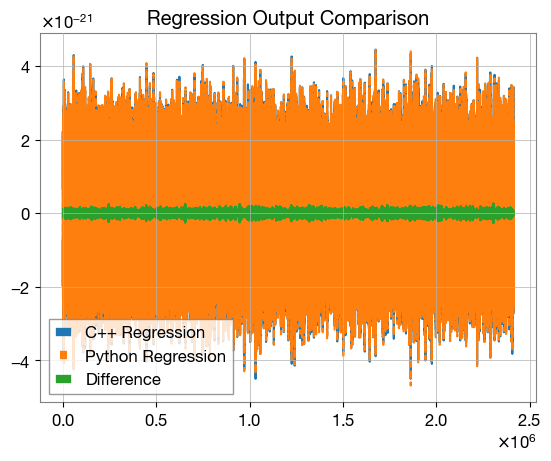

In [4]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

plt.plot(data_regressions[0].data, label='C++ Regression')
plt.plot(data_regressions_python[0], label='Python Regression', linestyle='dashed')
plt.plot(data_regressions[0].data - data_regressions_python[0], label='Difference')
plt.legend()
plt.title('Regression Output Comparison')
plt.show()

In [5]:
relative_diff = np.abs(data_regressions[0].data - data_regressions_python[0]) / np.max((np.abs(data_regressions[0].data)))
print(f"Max relative difference: {(relative_diff.max()):.6e}")

Max relative difference: 5.936944e-02


In [36]:
from pycwb.modules.data_conditioning.whitening_cwb import whitening_cwb
from pycwb.modules.data_conditioning.data_conditioning_python import whitening_python

res = [whitening_cwb(config, h) for h in data_regressions]
res_python = [whitening_python(config, h) for h in data_regressions]

26-02-24 16:54:50 - whitening_cwb - INFO - WDM filter max length = 6.00048828125 (sec)
26-02-24 16:54:51 - whitening_cwb - INFO - WDM filter max length = 6.00048828125 (sec)
26-02-24 16:54:51 - whitening_python - INFO - Python whitening: M=1024, beta=6, prec=10, Window=60.0s, Edge=10s
26-02-24 16:54:52 - whitening_python - INFO -   Conditioned strain length: 2414592
26-02-24 16:54:52 - whitening_python - INFO -   nRMS TF map shape: (1025, 58)
26-02-24 16:54:52 - whitening_python - INFO - Python whitening: M=1024, beta=6, prec=10, Window=60.0s, Edge=10s
26-02-24 16:54:53 - whitening_python - INFO -   Conditioned strain length: 2414592
26-02-24 16:54:53 - whitening_python - INFO -   nRMS TF map shape: (1025, 58)


In [37]:
conditioned_strains, nRMS_list = zip(*res)
conditioned_strains_python, nRMS_list_python = zip(*res_python)

In [38]:
conditioned_strains_python[0].data

array([-0.04129622, -0.08811576, -0.12685699, ...,  0.31865209,
        1.10864214,  0.10471105])

/Users/yumengxu/miniforge3/envs/pycwb_x64/lib/python3.11/site-packages/gwpy/plot/axes.py:194: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  super().draw(*args, **kwargs)
/Users/yumengxu/miniforge3/envs/pycwb_x64/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


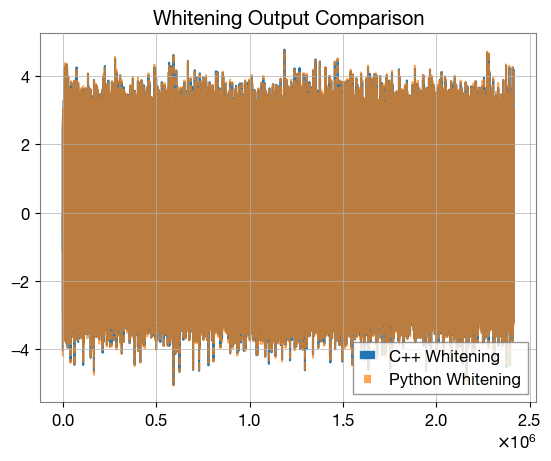

In [39]:
plt.plot(conditioned_strains[0].data.data, label='C++ Whitening')
plt.plot(conditioned_strains_python[0].data, label='Python Whitening', linestyle='dashed', alpha=0.7) 
# plt.plot(conditioned_strains[0].data.data - conditioned_strains_python[0].data, label='Difference')
plt.legend()
plt.title('Whitening Output Comparison')
plt.show()

In [40]:
conditioned_strains_relative_diff = np.abs(conditioned_strains[0].data.data - conditioned_strains_python[0].data) / np.max((np.abs(conditioned_strains[0].data.data)))
print(f"Max relative difference in conditioned strains: {(conditioned_strains_relative_diff.max()):.6e}")


Max relative difference in conditioned strains: 2.898259e-01


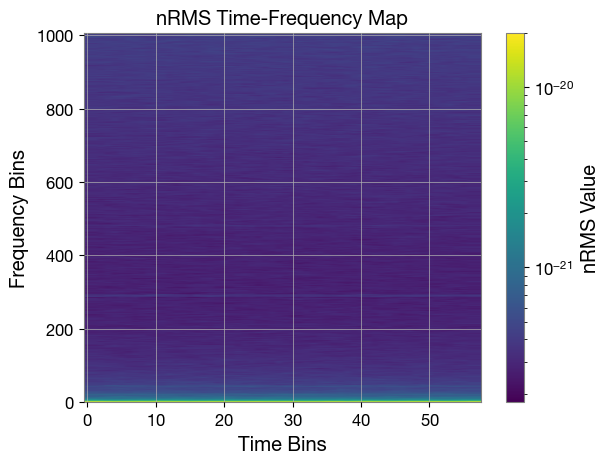

In [41]:
from pycwb.modules.cwb_conversions import convert_time_frequency_series_to_wseries, WSeries_to_matrix
from matplotlib.colors import LogNorm
data = np.random.lognormal(mean=0, sigma=1, size=(100, 100))

nRMS = WSeries_to_matrix(convert_time_frequency_series_to_wseries(nRMS_list[0]))
plt.imshow(nRMS[17:-1], aspect='auto', origin='lower', norm=LogNorm(vmin=nRMS[17:-1].min(), vmax=nRMS[17:-1].max()))
plt.colorbar(label='nRMS Value')
plt.title('nRMS Time-Frequency Map')
plt.xlabel('Time Bins')
plt.ylabel('Frequency Bins')
plt.show()

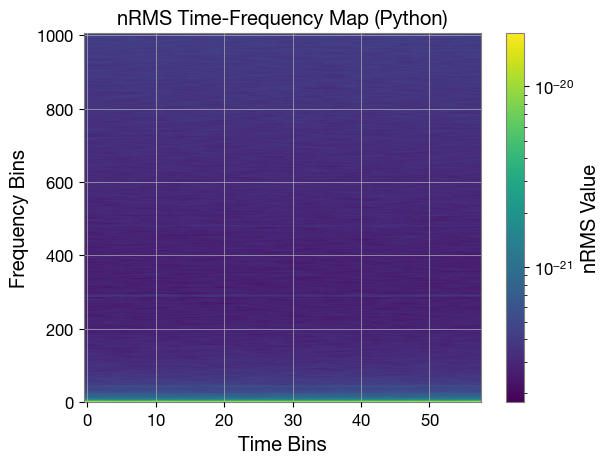

In [42]:
nRMS_py = nRMS_list_python[0].data
plt.imshow(nRMS_py[17:-1], aspect='auto', origin='lower', norm=LogNorm(vmin=nRMS_py[17:-1].min(), vmax=nRMS_py[17:-1].max()))
plt.colorbar(label='nRMS Value')
plt.title('nRMS Time-Frequency Map (Python)')
plt.xlabel('Time Bins')
plt.ylabel('Frequency Bins')
plt.show()

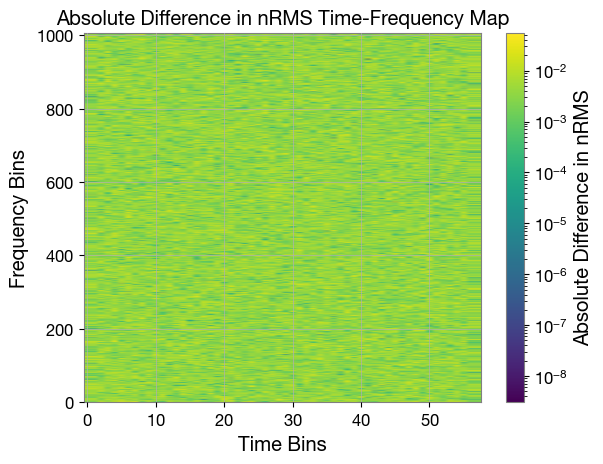

In [43]:
diff_nRMS = np.abs(nRMS[17:-1] - nRMS_py[17:-1]) / np.maximum(np.abs(nRMS[17:-1]), np.abs(nRMS_py[17:-1]), np.full_like(nRMS[17:-1], 1e-10))  # Avoid division by zero
plt.imshow(diff_nRMS, aspect='auto', origin='lower', norm=LogNorm(vmin=diff_nRMS.min(), vmax=diff_nRMS.max()))
plt.colorbar(label='Absolute Difference in nRMS')
plt.title('Absolute Difference in nRMS Time-Frequency Map')
plt.xlabel('Time Bins')
plt.ylabel('Frequency Bins')
plt.show()

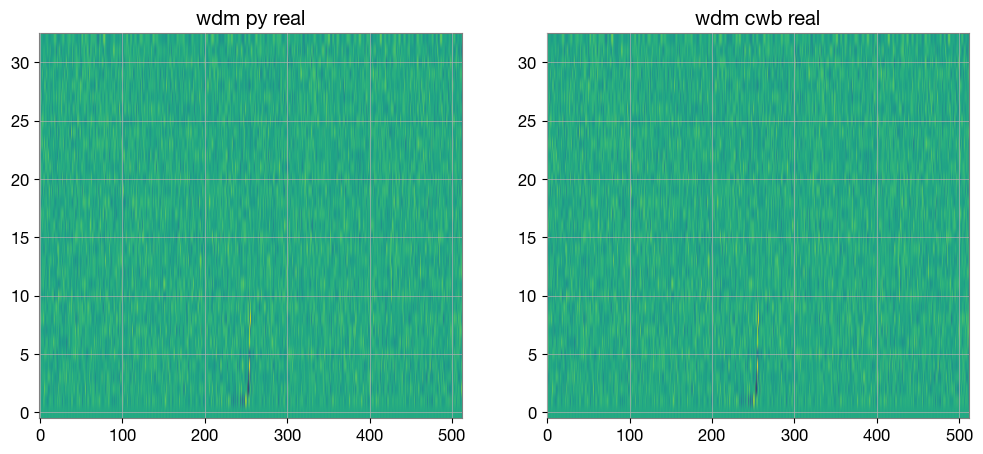

In [45]:
from wdm_wavelet.wdm import WDM

t_start = 1126259162.4 - 4
t_end = 1126259162.4 + 4

data_start = conditioned_strains[0].data.start_time
data_end = conditioned_strains[0].data.end_time

# crop the conditioned strains to the same time range for direct comparison
ts_cropped = conditioned_strains[0].data.crop(t_start - data_start, data_end - t_end)
ts_cropped_python = conditioned_strains_python[0].crop(t_start - data_start, data_end - t_end)
wdm = WDM(32, 64, 6, 10)
tf_map = wdm.t2w(ts_cropped_python)
tf_map_cwb = wdm.t2w(ts_cropped)



fig, axs = plt.subplots(1, 2, figsize=(12, 5))
# two real and diff
axs[0].imshow(tf_map.data.real, aspect="auto", origin="lower")
axs[0].set_title("wdm py real")
axs[1].imshow(tf_map_cwb.data.real, aspect="auto", origin="lower")
axs[1].set_title("wdm cwb real")
plt.show()

In [24]:
type(conditioned_strains[0].data)

pycbc.types.timeseries.TimeSeries